Source : https://ecco-v4-python-tutorial.readthedocs.io/ECCO_v4_Gradient_calc_on_native_grid.html#Part-2:-calculate-the-zonal-and-meridional-gradients-of-the-zonal-and-meridional-flow-fields

In [40]:
import numpy as np
from dask.distributed import Client
import cmocean
import xgcm
import ecco_v4_py as ecco

In [9]:
import dbof.preprocessing.preproc_llc_core_data as preproc_llc_core_data
import plotting.llc_plotting as llc_plotting
import dbof.llc4320_ingestion.get_raw_data as get_raw_data

### Helpers

In [94]:
def calculate_project_plot_var(arr, cmap, vmin=None, vmax=None, minper=0.0001, maxper=0.9999, symmetry=False):

    np_arr = arr.values
    if vmin is None:
        max = np.nanquantile(np_arr, maxper)
    else :
        max = vmax


    if vmax is None:
        min = np.nanquantile(np_arr, minper)
    else :
        min = vmin

    if (symmetry):
        max = abs(min)

    print (max)
    print (min)


    ecco.plot_proj_to_latlon_grid(ds_merge.XC,
                                      ds_merge.YC,
                                      np_arr,
                                      plot_type = 'pcolormesh',
                                      dx=0.1,
                                      dy=0.1,
                                      cmin=min,
                                      cmax=max,
                                      cmap=cmap,
                                      projection_type = 'robin',
                                      less_output = True)


# Get data from one snapshot

In [55]:
ts_per_hour = 144                       # model cadence: 25 s → 144 steps/hr

# First valid wind/forcing
start_record = 1180
first_it = 10368 + start_record * ts_per_hour

endpoint_url = 'https://mghp.osn.xsede.org'
LLC_FACES = range(13)

In [56]:
dask_client = Client()

C:\Users\Jake Tallman\PycharmProjects\dbof-in-native-grid\.venv1\Lib\site-packages\distributed\node.py:187: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 60469 instead
  warnings.warn(


In [57]:
co = get_raw_data.get_remote_gridfile(endpoint_url)
ds = get_raw_data.get_remote_llc_data(endpoint_url, first_it, LLC_FACES)

ds_grid = preproc_llc_core_data.process_llc4320_grid(co)
ds_merge = preproc_llc_core_data.process_llc4320(ds, ds_grid)

grid = xgcm.Grid(ds_grid, periodic=False)

KeyboardInterrupt: 

# Calculate Vorticity of U and V components

## Isolate U and V

In [15]:
#https://ecco-v4-python-tutorial.readthedocs.io/ECCO_v4_Gradient_calc_on_native_grid.html#Calculating-gradients-of-vector-fields-located-on-the-'u'-and-'v'-points-(vorticity/divergence)

# interpolate the ‘x’ and ‘y’ components of the flow field, u_x and v_y respectively, to the grid cell centers
# todo this may help or hurt the dask graph issues. Lets investigate when possible
u_x = ds_merge.U.copy(deep=True)
v_y = ds_merge.V.copy(deep=True)

# todo any issues with land after halo masking?
# # set land points to nan so that we don't get big gradients between ocean and land
# # ... the wet/dry mask for 'u' points is in the 'maskW' field
# # ... the wet/dry mask for 'v' points is in the 'maskS' field
# nan_land_mask_W = ecco_ds.maskW.where(ecco_ds.maskW.isel(k=0) > 0);
# nan_land_mask_S = ecco_ds.maskS.where(ecco_ds.maskS.isel(k=0) > 0);

<xarray.DataArray 'U' (face: 13, j: 4320, i_g: 4320)> Size: 970MB
dask.array<getitem, shape=(13, 4320, 4320), dtype=float32, chunksize=(1, 720, 360), chunktype=numpy.ndarray>
Coordinates:
  * face     (face) float64 104B 0.0 1.0 2.0 3.0 4.0 ... 8.0 9.0 10.0 11.0 12.0
  * j        (j) float64 35kB 0.0 1.0 2.0 3.0 ... 4.317e+03 4.318e+03 4.319e+03
  * i_g      (i_g) float64 35kB 0.0 1.0 2.0 ... 4.317e+03 4.318e+03 4.319e+03
    k        float64 8B 0.0
    k_l      float64 8B 0.0
    niter    float64 8B dask.array<chunksize=(), meta=np.ndarray>
    time     datetime64[ns] 8B 2011-11-01T04:00:00
Attributes:
    long_name:      Zonal Component of Velocity
    mate:           V
    standard_name:  sea_water_x_velocity
    units:          m s-1


uvel dimensions:  ('face', 'j', 'i_g')
uvel shape:       (13, 4320, 4320)

vvel dimensions: ('face', 'j_g', 'i')
vvel shape:       (13, 4320, 4320)


C:\Users\Jake Tallman\PycharmProjects\dbof-in-native-grid\.venv1\Lib\site-packages\plotting\llc_plotting.py:151: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


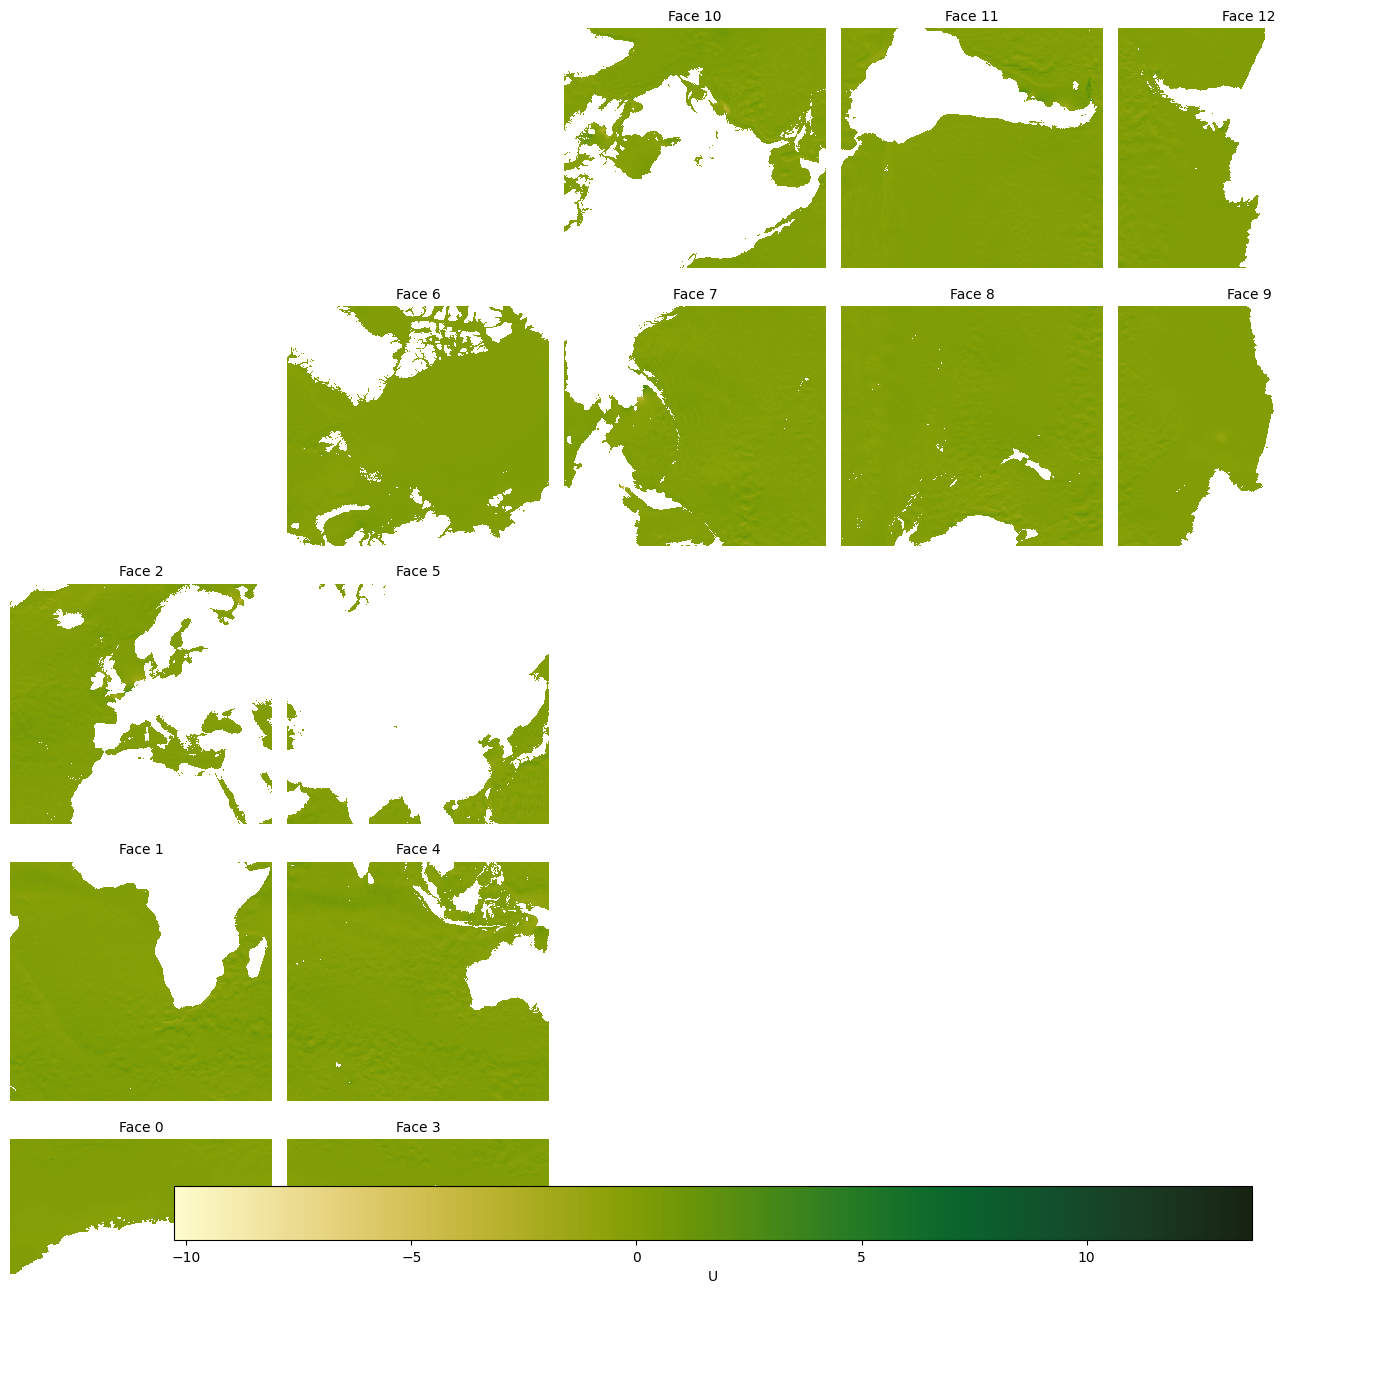

In [58]:
print(f'\nuvel dimensions:  {u_x.dims}')
print(f'uvel shape:       {u_x.shape}')
print(f'\nvvel dimensions: {v_y.dims}')
print(f'vvel shape:       {v_y.shape}')

llc_plotting.plot_llc_faces_layout(u_x, color_map = cmocean.cm.speed)

## Calculate the zonal and meridional components of flow from the u_x and v_y components

In [22]:
# u_x and v_y are located at the model's 'u' and 'v' points, respectively.
# interpolate the vectors to the cell centers at i,j
#vec_u_to_ij = XGCM_grid.interp_2d_vector({'X': u_x, 'Y': v_y},boundary='fill')
vec_u_to_ij = grid.interp(u_x, 'X', boundary='fill')
vec_v_to_ij = grid.interp(v_y, 'Y', boundary='fill')

# rotate the interpolated vectors to the zonal (lambda) and meridional (phi) basis
# Add the zonal components of the 'X' and 'Y' vectors
u_lambda       = vec_u_to_ij*ds_merge['CS'] - vec_v_to_ij*ds_merge['SN']

# Add the meridional components
v_phi          = vec_u_to_ij*ds_merge['SN'] + vec_v_to_ij*ds_merge['CS']

In [59]:
# confirm that the zonal and meridional components of the flow are at the tracer cell points [dimensions 'tile','i','j'] (13 tiles of 90x90)
print(f'\nu_lambda dimensions  : {u_lambda.dims}')
print(f'u_lambda shape       : {u_lambda.shape}')
print(f'\nv_phi dims   : {v_phi.dims}')
print(f'v_phi shape  : {v_phi.shape}')


u_lambda dimensions  : ('face', 'j', 'i')
u_lambda shape       : (13, 4320, 4320)

v_phi dims   : ('face', 'j', 'i')
v_phi shape  : (13, 4320, 4320)


In [29]:
# np_u_lambda = u_lambda.values # just for visualization
# np_v_phi = v_phi.values # just for visualization

2.112586
-2.222902


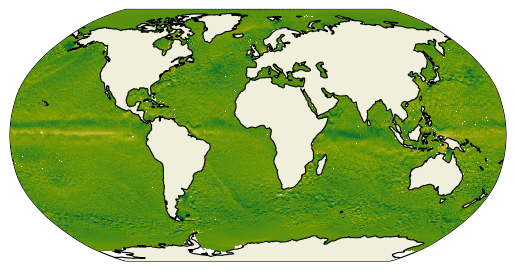

In [64]:
# should look meridional now
calculate_project_plot_var(u_lambda, cmap=cmocean.cm.speed)

# max = np.nanquantile(np_u_lambda, 0.9999)
# print (max)
# min = np.nanquantile(np_u_lambda, 0.0001)
# print (min)
#
# import ecco_v4_py as ecco
# ecco.plot_proj_to_latlon_grid(ds_merge.XC,
#                               ds_merge.YC,
#                               np_u_lambda,
#                               plot_type = 'pcolormesh',
#                               dx=0.5,
#                               dy=0.5,
#                               cmin=min,
#                               cmax=max,
#                               projection_type = 'robin',
#                               less_output = True)

2.8616872
-2.2262924


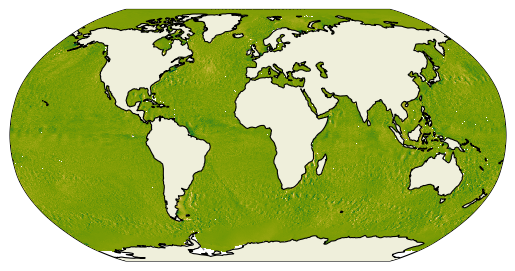

In [66]:
# should look zonal now
calculate_project_plot_var(v_phi, cmap=cmocean.cm.speed)

## Calculate the zonal and meridional gradients of the zonal field

In [67]:
# calcluate gradient of zonal component with respect to x and y

# calculate the gradient in the model 'x' direction
du_lambda_dx = grid.diff(u_lambda, 'X') / ds_merge.dxC

# calculate the gradient in the model 'y' direction
du_lambda_dy = grid.diff(u_lambda, 'Y') / ds_merge.dyC

print(f'du_lambda_dx dims: {du_lambda_dx.dims}')
print(f'du_lambda_dx shape: {du_lambda_dx.shape}')

print(f'\ndu_lambda_dy dims: {du_lambda_dy.dims}')
print(f'du_lambda_dy shape: {du_lambda_dy.shape}')

du_lambda_dx dims: ('face', 'j', 'i_g')
du_lambda_dx shape: (13, 4320, 4320)

du_lambda_dy dims: ('face', 'j_g', 'i')
du_lambda_dy shape: (13, 4320, 4320)


In [68]:
# interpolate the gradients from cell boundaries to the cell centers

#grid.interp_2d_vector({'X': du_lambda_dx, 'Y': du_lambda_dy},boundary='fill')
grad_u_lambda_to_ij_X = grid.interp(du_lambda_dx, 'X', boundary='fill')
grad_u_lambda_to_ij_Y = grid.interp(du_lambda_dy, 'Y', boundary='fill')

In [ ]:
# rotate to zonal and meridional directions
# Add the zonal components of the 'X' and 'Y' vector components
du_lambda_dlambda    = grad_u_lambda_to_ij_X*ds_merge['CS'] - grad_u_lambda_to_ij_Y*ds_merge['SN']

# Add the meridional components
du_lambda_dphi       = grad_u_lambda_to_ij_X*ds_merge['SN'] + grad_u_lambda_to_ij_Y*ds_merge['CS']

2.7854021e-05
-2.7854021e-05


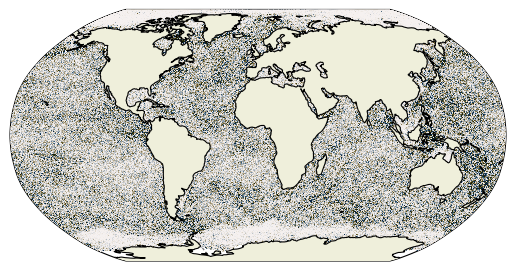

In [93]:
# Zonal Gradient of zonal flow field
calculate_project_plot_var(du_lambda_dlambda, cmap=cmocean.cm.diff, minper=0.02, maxper=0.98, symmetry=True)

In [ ]:
# Meridional Gradient of zonal field
calculate_project_plot_var(du_lambda_dphi, cmap=cmocean.cm.diff, minper=0.02, maxper=0.98, symmetry=True)

3.0357362e-05
-3.0357362e-05


C:\Users\Jake Tallman\PycharmProjects\dbof-in-native-grid\.venv1\Lib\site-packages\plotting\llc_plotting.py:151: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


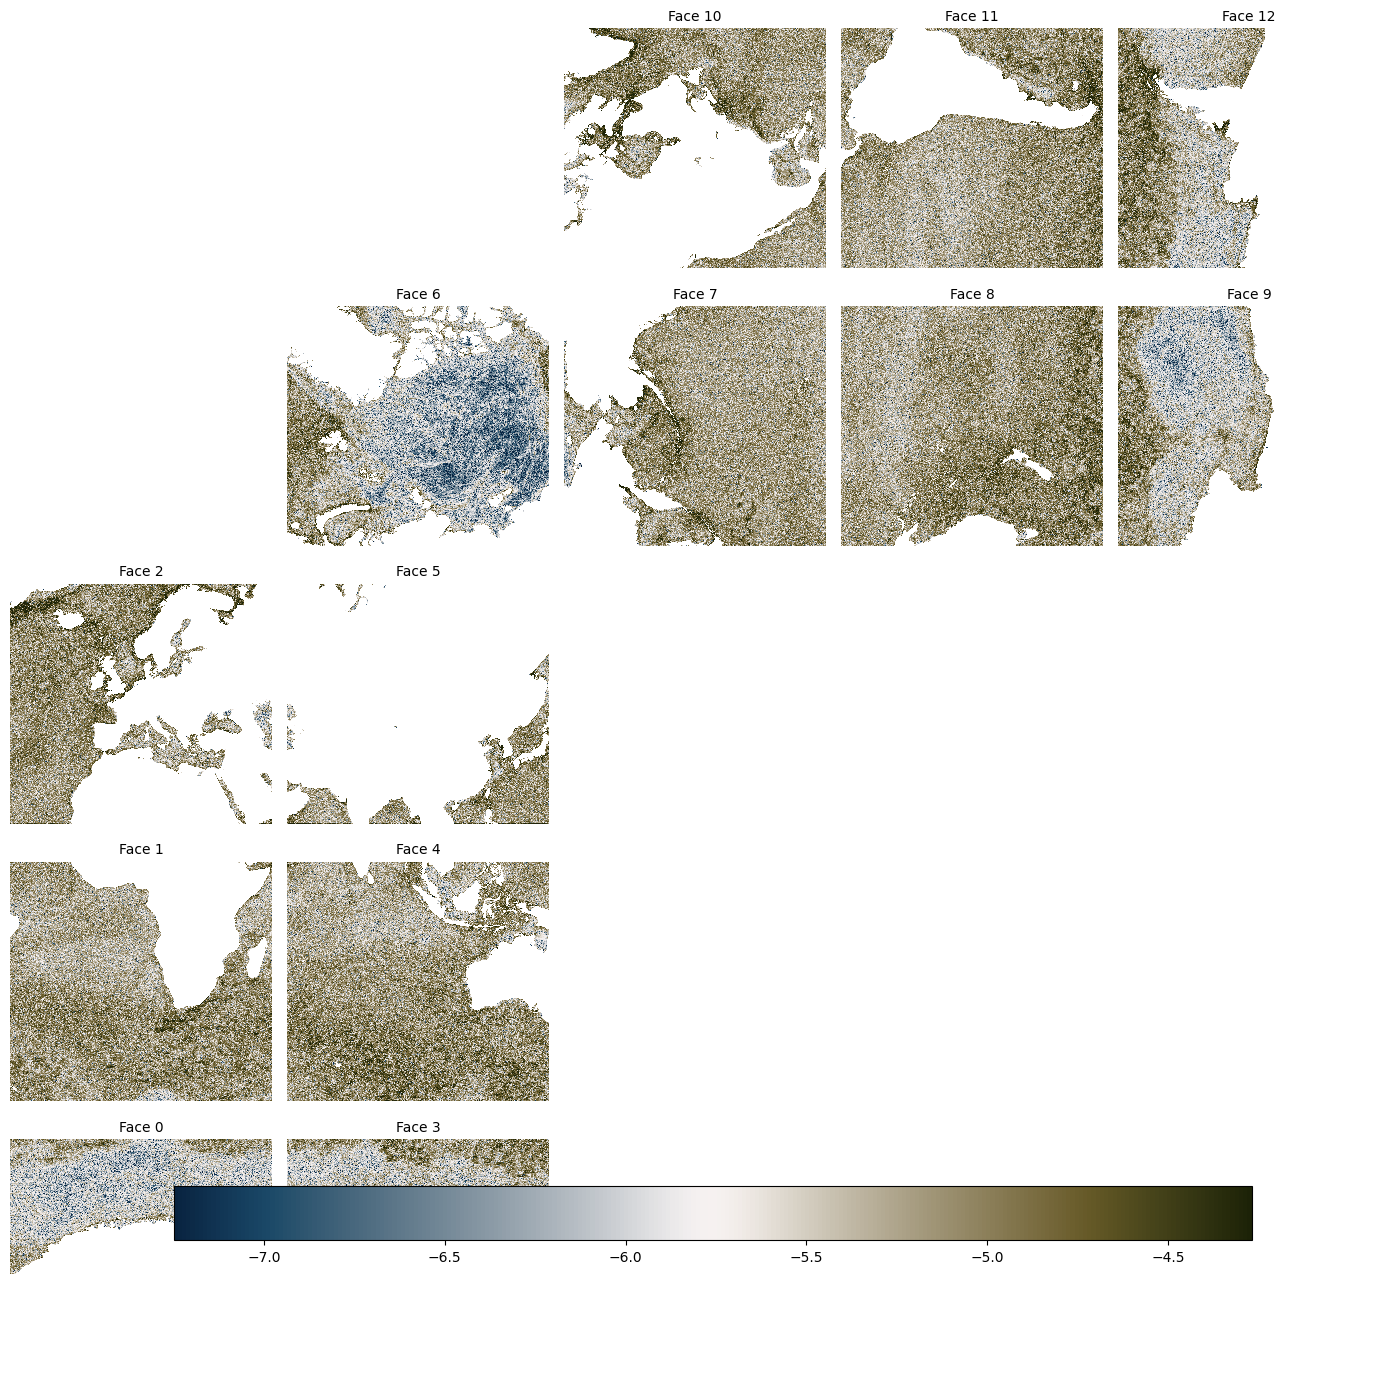

In [90]:
#llc_plotting.plot_log_faces_layout(du_lambda_dphi, color_map = cmocean.cm.diff)

## Calculate the zonal and meridional gradients of the zonal field


In [ ]:
# todo left off here

# calculate the gradient in the model 'x' direction
dv_phi_dx = grid.diff(v_phi, 'X') / ds_merge.dxC

# calculate the gradient in the model 'y' direction
dv_phi_dy = grid.diff(v_phi, 'Y') / ds_merge.dyC